In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['Species'] = iris.target_names[iris.target]

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSpecies in dataset:")
print(df['Species'].value_counts())

Shape: (150, 5)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Species in dataset:
Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [2]:
# Encode species to numbers
le = LabelEncoder()
X = df.drop('Species', axis=1)
y = le.fit_transform(df['Species'])  # setosa=0, versicolor=1, virginica=2

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train 3 different models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', random_state=42)
}

# Test all 3 and compare
print("Model Comparison:")
print("-" * 40)
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"{name}: {accuracy:.2%}")

Model Comparison:
----------------------------------------
Decision Tree: 100.00%
K-Nearest Neighbors: 100.00%
Support Vector Machine: 100.00%


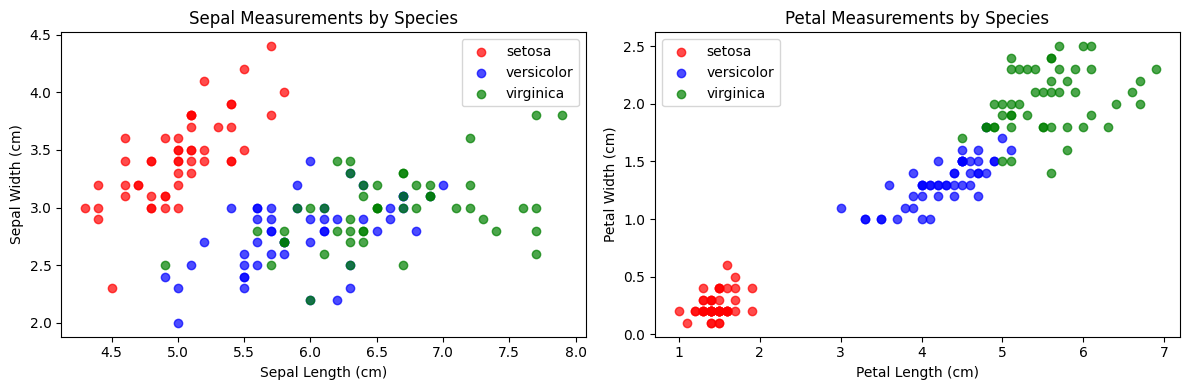


Prediction for new flower [[5.1, 3.5, 1.4, 0.2]]:
Predicted species: setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [3]:
# Visualize the differences between species
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: Sepal measurements
for species, color in zip(['setosa', 'versicolor', 'virginica'],
                           ['red', 'blue', 'green']):
    mask = df['Species'] == species
    axes[0].scatter(df[mask]['sepal length (cm)'],
                   df[mask]['sepal width (cm)'],
                   label=species, color=color, alpha=0.7)
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].set_title('Sepal Measurements by Species')
axes[0].legend()

# Plot 2: Petal measurements
for species, color in zip(['setosa', 'versicolor', 'virginica'],
                           ['red', 'blue', 'green']):
    mask = df['Species'] == species
    axes[1].scatter(df[mask]['petal length (cm)'],
                   df[mask]['petal width (cm)'],
                   label=species, color=color, alpha=0.7)
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].set_title('Petal Measurements by Species')
axes[1].legend()

plt.tight_layout()
plt.show()

# Best model prediction example
best_model = models['Support Vector Machine']
sample = [[5.1, 3.5, 1.4, 0.2]]  # a new flower
prediction = best_model.predict(sample)
print(f"\nPrediction for new flower {sample}:")
print(f"Predicted species: {le.inverse_transform(prediction)[0]}")